<p style="background-color:#f8f9fa;
          padding:18px;
          color:#111;
          font-size:16px;
          border-width:2px;
          border-color:#e0e0e0;
          border-style:solid;
          border-radius:6px">
⛳ <strong>Ultimate NeuroGolf ONNX Surgery Pipeline</strong><br><br>
This notebook applies a stacked set of <strong>verified ONNX graph surgeries</strong> to reduce
NeuroGolf cost while preserving model behavior whenever possible.<br><br>
The optimization pipeline is applied from safest to riskiest:<br><br>
⚡ <strong>Generic ONNX Simplification</strong> — onnxoptimizer + onnxsim graph cleanup<br>
🧼 <strong>Safe Lossless Cleanup</strong> — prune unused tensors, deduplicate weights, remove Identity nodes<br>
🧬 <strong>Index Surgery</strong> — shrink redundant int/index metadata and Slice bookkeeping<br>
📡 <strong>Broadcast Compression</strong> — compress repeated tensors using ONNX broadcasting rules<br>
🔁 <strong>Structural Micro-Rewrites</strong> — replace expensive equivalent graph patterns with cheaper forms<br>
🧪 <strong>FP16 Surgery</strong> — audited half-precision conversion for additional memory savings<br><br>
🎯 Same outputs when accepted. Lower memory. Fewer parameters. Higher score.
</p>

# ⚙️ Setup

In [1]:
class Config:
    use_onnx_simplification = True
    use_safe_cleanup = False
    use_index_surgery = False
    use_broadcast_compression = False
    use_micro_rewrites = False
    use_fp16_surgery = False

$$ $$

 ## 📦 Imports

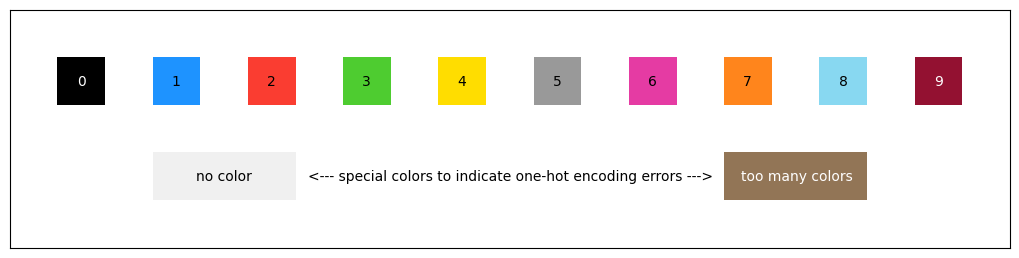

In [2]:
import sys
sys.path.append("/kaggle/input/competitions/neurogolf-2026/neurogolf_utils")
from neurogolf_utils import *
show_legend()

In [3]:
import math, glob, os, gc
import copy
from collections import defaultdict, Counter
from tqdm.auto import tqdm

import pandas as pd
import numpy as np

import onnx
from onnx import helper, TensorProto, numpy_helper
import onnxruntime

$$ $$
## ƒ Utils

In [4]:
def score_task(task_num, network, verify_on_data = False):
    """Returns (points, memory, params) or None if failed."""
    filename = f"task{task_num:03d}.onnx"
    onnx.save(network, filename)
    if not check_network(filename):
        return None

    try:
        sanitized = onnx.load(filename)
        for node in sanitized.graph.node:
            node.name = node.output[0]
            if "kernel_time" in node.name:
                return None
        options = onnxruntime.SessionOptions()
        options.enable_profiling = True
        options.graph_optimization_level = onnxruntime.GraphOptimizationLevel.ORT_DISABLE_ALL
        options.profile_file_prefix = f"{task_num:03}"
        session = onnxruntime.InferenceSession(sanitized.SerializeToString(), options)
    except Exception:
        return None

    if verify_on_data:
        examples = load_examples(task_num)
        
        agi_r, agi_w, _ = verify_subset(session, examples["train"] + examples["test"])
        if agi_w > 0:
            return None
            
        gen_r, gen_w, _ = verify_subset(session, examples["arc-gen"])
        if gen_w > 0:
            return None  # incorrect

    memory, params = score_network(sanitized, session.end_profiling())
    if memory is None or params is None or memory < 0 or params < 0:
        return None

    points = max(1.0, 25.0 - math.log(max(1.0, memory + params)))
    return points, memory, params

In [5]:
def perform_surgery(surgeon, verify_on_data = True):
    improved = []
    failures = []

    for task_num in tqdm(range(1, 401)):
        path = f"{SRC}/task{task_num:03d}.onnx"
    
        if not os.path.exists(path):
            continue
    
        network = onnx.load(path)
    
        score_before, mem_before, params_before = task_num_to_score[task_num]
        
        try:
            optimized, report = surgeon(copy.deepcopy(network))
    
            onnx.checker.check_model(optimized)
    
            score_after, mem_after, params_after = score_task(
                task_num,
                optimized,
                verify_on_data=verify_on_data
            )
    
            delta = score_after - score_before
    
            if delta > 0:
                improved.append(
                    (
                        task_num,
                        mem_before,
                        mem_after,
                        params_before,
                        params_after,
                        score_before,
                        score_after,
                        delta,
                        report
                    )
                )
                print(f"  {task_num:03d}    {mem_before:>8}   {mem_after:>8}   {params_before:>12}   {params_after:>11}   +{delta:.4f}")
                task_num_to_score[task_num] = (score_after, mem_after, params_after)
                
                onnx.save(optimized, path)
    
        except Exception as e:
            failures.append((task_num, str(e)[:80]))

    !rm *.onnx 2>/dev/null
    !rm *.json 2>/dev/null
    return improved, failures

$$ $$

## 📊 Load Public Submission

In [6]:
!rm -r /kaggle/working/submission 2>/dev/null
!cp /kaggle/input/notebooks/franksunp/compact-onnx-artifact-starter-ii/submission.zip /kaggle/working/submission.zip
!unzip -q /kaggle/working/submission.zip -d /kaggle/working/submission
!rm /kaggle/working/submission.zip
!ls -la submission

total 2448
drwxr-xr-x 2 root root  16384 Jul 12 14:27 .
drwxr-xr-x 3 root root   4096 Jul 12 14:27 ..
-rw------- 1 root root    795 Jan  1  1980 task001.onnx
-rw------- 1 root root  12833 Jan  1  1980 task002.onnx
-rw------- 1 root root   1309 Jan  1  1980 task003.onnx
-rw------- 1 root root   1433 Jan  1  1980 task004.onnx
-rw------- 1 root root   4692 Jan  1  1980 task005.onnx
-rw------- 1 root root    877 Jan  1  1980 task006.onnx
-rw------- 1 root root    840 Jan  1  1980 task007.onnx
-rw------- 1 root root   7009 Jan  1  1980 task008.onnx
-rw------- 1 root root   2039 Jan  1  1980 task009.onnx
-rw------- 1 root root   1491 Jan  1  1980 task010.onnx
-rw------- 1 root root   1525 Jan  1  1980 task011.onnx
-rw------- 1 root root   2240 Jan  1  1980 task012.onnx
-rw------- 1 root root   2325 Jan  1  1980 task013.onnx
-rw------- 1 root root   2751 Jan  1  1980 task014.onnx
-rw------- 1 root root   3774 Jan  1  1980 task015.onnx
-rw------- 1 root root    158 Jan  1  1980 task016.onnx
-r

In [7]:
SRC = "/kaggle/working/submission"

$$ $$

## 💯 Initial Score

In [8]:
task_paths = sorted(glob.glob(f"{SRC}/task*.onnx"))
INITIAL_SCORE = 0.0
task_num_to_score = dict()

for path in tqdm(task_paths):
    task_num = int(os.path.basename(path).split(".")[0].replace("task",""))
    
    try:
        network = onnx.load(path)
        points, mem, params = score_task(task_num, network, verify_on_data = False)

    except Exception as e:
        print(f"[{task_num}] {e}")
        print(f"----------------------------------------\n")
        points, mem, params = 0, None, None


    
    INITIAL_SCORE += points
    task_num_to_score[task_num] = (points, mem, params)

!rm *.json 2>/dev/null
!rm *.onnx 2>/dev/null
print(f"💯 Initial Score: {INITIAL_SCORE:.5f}")

  0%|          | 0/400 [00:00<?, ?it/s]

💯 Initial Score: 7268.40463


$$ $$

# 🧹 Optimizations

## ⚡ Generic ONNX Simplification

<p style="background-color:#fff9e6;
          padding:18px;
          color:#111;
          font-size:16px;
          border-width:2px;
          border-color:#f3d87a;
          border-style:solid;
          border-radius:6px">
⚡ <strong>Generic ONNX Simplification</strong><br><br>
Before applying custom NeuroGolf surgeries, every graph is passed through the standard ONNX optimization stack.<br><br>
⚙️ <strong>onnxoptimizer</strong> — removes dead nodes, eliminates redundant operations, folds constants, and applies graph-level cleanup passes.<br>
🪄 <strong>onnxsim (ONNX Simplifier)</strong> — simplifies graph structure, propagates constants, removes unnecessary tensors, and collapses redundant patterns into smaller equivalent graphs.<br><br>
These tools are widely used across the ONNX ecosystem and often recover free score improvements before task-specific optimization begins.<br><br>
🎯 Same computation. Cleaner graph. Better starting point for later surgeries.
</p>

### Utils

In [9]:
import onnxsim

def apply_generic_onnx_simplification(model):
    optimized = copy.deepcopy(model)
    report = {}

    try:
        optimized = onnxscript.optimizer.optimize(
            copy.deepcopy(network),
            num_iterations=32,
            onnx_shape_inference=True,
        )
        report["onnxoptimizer"] = "ok"
    except Exception as e:
        report["onnxoptimizer"] = f"failed: {str(e)[:100]}"

    try:
        simplified, ok = onnxsim.simplify(optimized)
        if ok:
            optimized = simplified
            report["onnxsim"] = "ok"
        else:
            report["onnxsim"] = "not_ok"
    except Exception as e:
        report["onnxsim"] = f"failed: {str(e)[:100]}"

    return optimized, report

In [10]:
if Config.use_onnx_simplification:
    print(f"⚡{'Task':>4} {'Mem Before':>10} {'Mem After':>10} {'Params Before':>14} {'Params After':>13} {'Score Δ':>8}")
    print(f"{'─'*6} {'─'*10} {'─'*10} {'─'*14} {'─'*13} {'─'*8}")
    
    improved, failures = perform_surgery(apply_generic_onnx_simplification, verify_on_data = False)
    
    improved.sort(key=lambda x: -x[7])
    total_gain = sum(r[7] for r in improved)
    print(f"\n📊 Total score gain: +{total_gain:.4f} across {len(improved)} tasks")
    
    if failures:
        print(f"⚠️  {len(failures)} tasks failed surgery")

⚡Task Mem Before  Mem After  Params Before  Params After  Score Δ
────── ────────── ────────── ────────────── ───────────── ────────


  0%|          | 0/400 [00:00<?, ?it/s]

  005        6452       5923            195           722   +0.0003
  396        3482       3481             80            80   +0.0003

📊 Total score gain: +0.0006 across 2 tasks


$$ $$

## 🧼 Safe Cleanup

<p style="background-color:#eef6ff;
          padding:18px;
          color:#111;
          font-size:16px;
          border-width:2px;
          border-color:#b6d8ff;
          border-style:solid;
          border-radius:6px">
🧼 <strong>Safe Lossless Cleanup</strong><br><br>
The first stage of the optimizer removes waste that contributes to the NeuroGolf
cost function without changing graph behavior.<br><br>
✂️ <strong>Prune Unused Initializers</strong> — remove tensors that are never consumed by any node.<br>
🔗 <strong>Deduplicate Initializers</strong> — merge identical tensors stored multiple times under different names.<br><br>
🎯 Same outputs. Fewer parameters. Free score improvements.
</p>

### Utils

In [11]:
def cleanup_unused_initializers(model):
    """
    Remove initializers that are never referenced by any node.

    Returns:
        (model, saved_params)
        (None, 0) if nothing changed
    """
    graph = model.graph

    used = set()
    for node in graph.node:
        used.update(inp for inp in node.input if inp)

    to_remove = [
        init
        for init in graph.initializer
        if init.name not in used
    ]

    if not to_remove:
        return None, 0

    saved = 0

    for init in to_remove:
        graph.initializer.remove(init)

        params = (
            int(np.prod(init.dims))
            if init.dims
            else 1
        )

        saved += params

    return model, saved


def initializer_key(init):
    """
    Exact initializer fingerprint:
    (dtype, shape, raw bytes)
    """
    arr = numpy_helper.to_array(init)

    return (
        arr.dtype.str,
        tuple(arr.shape),
        arr.tobytes()
    )


def find_duplicate_initializers(model):
    """
    Return groups of identical initializers.
    """
    groups = defaultdict(list)

    for init in model.graph.initializer:
        groups[initializer_key(init)].append(init.name)

    return [
        names
        for names in groups.values()
        if len(names) > 1
    ]


def deduplicate_initializers(model):
    """
    Merge identical initializers and
    rewire graph inputs to a canonical tensor.

    Returns:
        (model, num_deduplicated)
    """
    groups = defaultdict(list)

    for init in model.graph.initializer:
        groups[initializer_key(init)].append(init.name)

    replace = {}

    for names in groups.values():

        if len(names) <= 1:
            continue

        canonical = sorted(
            names,
            key=lambda s: (len(s), s)
        )[0]

        for name in names:
            if name != canonical:
                replace[name] = canonical

    if not replace:
        return model, 0

    # Rewire node inputs
    for node in model.graph.node:
        for i, name in enumerate(node.input):
            if name in replace:
                node.input[i] = replace[name]

    # Remove orphaned initializers
    used = {
        name
        for node in model.graph.node
        for name in node.input
        if name
    }

    kept = [
        init
        for init in model.graph.initializer
        if init.name in used
    ]

    del model.graph.initializer[:]
    model.graph.initializer.extend(kept)

    return model, len(replace)



def eliminate_identity_nodes(model):
    graph_outputs = {out.name for out in model.graph.output}
    replacements = {}

    for node in model.graph.node:
        if node.op_type != "Identity":
            continue
        if len(node.input) != 1 or len(node.output) != 1:
            continue
        if node.output[0] in graph_outputs:
            continue

        replacements[node.output[0]] = node.input[0]

    if not replacements:
        return 0, 0

    def resolve(name):
        seen = set()
        while name in replacements and name not in seen:
            seen.add(name)
            name = replacements[name]
        return name

    rewired = 0
    kept_nodes = []

    for node in model.graph.node:
        for i, name in enumerate(node.input):
            if name in replacements:
                node.input[i] = resolve(name)
                rewired += 1

        if node.op_type == "Identity" and node.output and node.output[0] in replacements:
            continue

        kept_nodes.append(node)

    removed = len(model.graph.node) - len(kept_nodes)

    del model.graph.node[:]
    model.graph.node.extend(kept_nodes)

    return removed, rewired


def apply_safe_lossless_cleanup(model):
    """
    Apply safe lossless cleanup:
      1. Remove unused initializers
      2. Deduplicate identical initializers
      3. Remove redundant Identity nodes

    Returns:
        optimized_model, report
    """
    optimized = copy.deepcopy(model)

    report = {
        "pruned_initializers": 0,
        "pruned_params": 0,
        "deduplicated_initializers": 0,
        "identity_removed": 0,
        "identity_rewired": 0,
    }

    # 1. Prune unused initializers
    pruned_model, saved_params = cleanup_unused_initializers(optimized)
    if pruned_model is not None:
        optimized = pruned_model
        report["pruned_initializers"] = 1
        report["pruned_params"] = saved_params

    # 2. Deduplicate initializers
    optimized, dedup_count = deduplicate_initializers(optimized)
    report["deduplicated_initializers"] = dedup_count

    # 3. Remove Identity nodes
    identity_removed, identity_rewired = eliminate_identity_nodes(optimized)
    report["identity_removed"] = identity_removed
    report["identity_rewired"] = identity_rewired

    if identity_removed:
        # value_info may reference removed tensors
        del optimized.graph.value_info[:]

    return optimized, report

In [12]:
if Config.use_safe_cleanup:    
    print(f"🧼{'Task':>4} {'Mem Before':>10} {'Mem After':>10} {'Params Before':>14} {'Params After':>13} {'Score Δ':>8}")
    print(f"{'─'*6} {'─'*10} {'─'*10} {'─'*14} {'─'*13} {'─'*8}")
    
    improved, failures = perform_surgery(apply_safe_lossless_cleanup, verify_on_data = False)
    
    improved.sort(key=lambda x: -x[7])
    total_gain = sum(r[7] for r in improved)
    print(f"\n📊 Total score gain: +{total_gain:.4f} across {len(improved)} tasks")
    
    if failures:
        print(f"⚠️  {len(failures)} tasks failed surgery")

$$ $$

## 🧬 Index Surgery

<p style="background-color:#f3f0ff;
          padding:18px;
          color:#111;
          font-size:16px;
          border-width:2px;
          border-color:#d7ccff;
          border-style:solid;
          border-radius:6px">
🧬 <strong>Index Surgery</strong><br><br>
NeuroGolf graphs often carry expensive indexing metadata: repeated <code>int64</code>
shape tensors, redundant <code>Slice</code> axes, and tiny constants that do not need
64-bit precision.<br><br>
This stage shrinks those tensors while preserving graph behavior:<br><br>
🔢 <strong>Int64 → Int32 Narrowing</strong> — downcast index tensors when every consumer accepts <code>int32</code>.<br>
🧬 <strong>Shape-Index Aliasing</strong> — merge repeated small integer tensors used for shape/index metadata.<br>
🪓 <strong>Slice Index Cleanup</strong> — remove default <code>axes</code> and <code>steps</code> inputs when they match ONNX defaults.<br>
🕳️ <strong>Axes-Hole Surgery</strong> — remove redundant default <code>axes</code> while preserving non-default <code>steps</code> via optional input slots.<br><br>
🎯 Same indexing. Fewer constants. Higher score.
</p>

### Utils

In [13]:
INT32_SAFE_INPUTS = {
    # Gather: input 1 (indices) accepts int32
    ("Gather", 1),
    # GatherElements: input 1 (indices)
    ("GatherElements", 1),
    # ScatterElements: input 1 (indices)
    ("ScatterElements", 1),
    # OneHot: input 0 (indices)
    ("OneHot", 0),
    # Cast: accepts anything
    ("Cast", 0),
    # Add/Sub/Mul/Div: accept int32
    ("Add", 0), ("Add", 1),
    ("Sub", 0), ("Sub", 1),
    ("Mul", 0), ("Mul", 1),
    ("Div", 0), ("Div", 1),
    ("Mod", 0), ("Mod", 1),
    # Comparison ops
    ("Equal", 0), ("Equal", 1),
    ("Less", 0), ("Less", 1),
    ("Greater", 0), ("Greater", 1),
    ("LessOrEqual", 0), ("LessOrEqual", 1),
    ("GreaterOrEqual", 0), ("GreaterOrEqual", 1),
    # Clip
    ("Clip", 0), ("Clip", 1), ("Clip", 2),
    # Where: condition is bool, but int inputs at 1,2
    ("Where", 1), ("Where", 2),
    # Min/Max (variadic, all positions)
    ("Min", 0), ("Min", 1), ("Min", 2), ("Min", 3),
    ("Max", 0), ("Max", 1), ("Max", 2), ("Max", 3),
    # Concat
    ("Concat", 0), ("Concat", 1), ("Concat", 2), ("Concat", 3),
    ("Concat", 4), ("Concat", 5), ("Concat", 6), ("Concat", 7),
    # Squeeze/Unsqueeze input 0 (data) — axes input must stay int64
    ("Squeeze", 0),
    ("Unsqueeze", 0),
    # ReduceSum etc — data input (pos 0) accepts int32
    ("ReduceSum", 0),
    ("ReduceMax", 0),
    ("ReduceMin", 0),
    ("ReduceMean", 0),
    ("ReduceProd", 0),
    # Abs, Neg, Sign
    ("Abs", 0),
    ("Neg", 0),
    ("Sign", 0),
    # Flatten
    ("Flatten", 0),
}

# Ops whose specific inputs REQUIRE int64 — never convert these
INT64_REQUIRED = {
    ("Reshape", 1),       # shape must be int64
    ("Slice", 1),         # starts
    ("Slice", 2),         # ends
    ("Slice", 3),         # axes
    ("Slice", 4),         # steps
    ("Pad", 1),           # pads
    ("Tile", 1),          # repeats
    ("Expand", 1),        # shape
    ("GatherND", 1),      # indices must be int64
    ("ScatterND", 1),     # indices must be int64
    ("Squeeze", 1),       # axes (opset 13+)
    ("Unsqueeze", 1),     # axes (opset 13+)
    ("ReduceSum", 1),     # axes (opset 13+)
    ("ReduceMax", 1),     # axes (opset 13+)
    ("ReduceMin", 1),     # axes (opset 13+)
}

SHAPE_INDEX_OP_INPUTS = {
    ("Gather", 1),
    ("GatherElements", 1),
    ("ScatterElements", 1),
    ("Slice", 1),
    ("Slice", 2),
    ("Slice", 3),
    ("Slice", 4),
    ("Reshape", 1),
    ("Unsqueeze", 1),
    ("Squeeze", 1),
    ("Pad", 1),
    ("Tile", 1),
    ("Expand", 1),
}


def build_consumer_map(graph):
    """Map tensor_name -> list of (node, input_position)."""
    consumers = defaultdict(list)
    for node in graph.node:
        for pos, inp_name in enumerate(node.input):
            if inp_name:
                consumers[inp_name].append((node, pos))
    return consumers


def is_safe_to_narrow(tensor_name, consumers):
    """Check if ALL consumers of this tensor accept int32 at their input position."""
    if tensor_name not in consumers:
        # No consumers = unused initializer, safe (will be pruned anyway)
        return True
    
    for node, pos in consumers[tensor_name]:
        key = (node.op_type, pos)
        if key in INT64_REQUIRED:
            return False
        if key not in INT32_SAFE_INPUTS:
            # Unknown op/position — be conservative, skip
            return False
    return True


def narrow_initializers(model):
    """Convert int64 initializers to int32 where safe."""
    graph = model.graph
    consumers = build_consumer_map(graph)
    
    converted = 0
    bytes_saved = 0
    
    for i, init in enumerate(graph.initializer):
        arr = numpy_helper.to_array(init)
        if arr.dtype != np.int64:
            continue
        
        # Check values fit in int32
        if arr.size > 0:
            if arr.min() < np.iinfo(np.int32).min or arr.max() > np.iinfo(np.int32).max:
                continue
        
        # Check all consumers accept int32
        if not is_safe_to_narrow(init.name, consumers):
            continue
        
        # Convert
        arr32 = arr.astype(np.int32)
        new_init = numpy_helper.from_array(arr32, init.name)
        graph.initializer[i].CopyFrom(new_init)
        
        converted += 1
        bytes_saved += arr.nbytes - arr32.nbytes
    
    return model, converted, bytes_saved


def insert_cast_after_argmax(model):
    """Insert Cast(int32) after ArgMax/ArgMin if downstream accepts it."""
    graph = model.graph
    consumers = build_consumer_map(graph)
    
    inserted = 0
    new_nodes = []
    
    for node in graph.node:
        new_nodes.append(node)
        
        if node.op_type not in ("ArgMax", "ArgMin"):
            continue
        
        output_name = node.output[0]
        
        # Check if all consumers accept int32
        if not is_safe_to_narrow(output_name, consumers):
            continue
        
        # Also skip if output is the graph output
        graph_output_names = {o.name for o in graph.output}
        if output_name in graph_output_names:
            continue
        
        # Rename original output, insert Cast
        old_name = output_name
        new_name = old_name + "_i64"
        node.output[0] = new_name
        
        cast_node = helper.make_node("Cast", [new_name], [old_name], to=TensorProto.INT32)
        new_nodes.append(cast_node)
        inserted += 1
    
    if inserted > 0:
        del graph.node[:]
        graph.node.extend(new_nodes)
    
    return model, inserted


def apply_int32_downcasting(model):
    """Apply all int64→int32 optimizations."""
    model = copy.deepcopy(model)
    
    model, init_converted, init_bytes_saved = narrow_initializers(model)
    model, casts_inserted = insert_cast_after_argmax(model)
    
    return model, {
        "init_converted": init_converted,
        "init_bytes_saved": init_bytes_saved,
        "casts_inserted": casts_inserted,
    }


def build_consumer_map(graph):
    consumers = defaultdict(list)
    for node in graph.node:
        for pos, inp_name in enumerate(node.input):
            if inp_name:
                consumers[inp_name].append((node, pos))
    return consumers

def dedup_tiny_shape_index_initializers(model):
    model = copy.deepcopy(model)
    graph = model.graph
    consumers = build_consumer_map(graph)

    key_to_name = {}
    rewires = {}
    remove_names = set()
    deduped = 0

    for init in graph.initializer:
        arr = numpy_helper.to_array(init)

        # Only tiny integer tensors.
        if arr.dtype not in (np.int32, np.int64):
            continue
        if arr.size > 8:
            continue

        # Only safe shape/index metadata consumers.
        ok = True
        for node, pos in consumers.get(init.name, []):
            if (node.op_type, pos) not in SHAPE_INDEX_OP_INPUTS:
                ok = False
                break

        if not ok:
            continue

        key = (arr.dtype.str, arr.shape, arr.tobytes())

        if key not in key_to_name:
            key_to_name[key] = init.name
        else:
            rewires[init.name] = key_to_name[key]
            remove_names.add(init.name)
            deduped += 1

    if deduped == 0:
        return model, {"dedup_tiny_shape_index_initializers": 0}

    for node in graph.node:
        for i in range(len(node.input)):
            if node.input[i] in rewires:
                node.input[i] = rewires[node.input[i]]

    kept = [init for init in graph.initializer if init.name not in remove_names]
    del graph.initializer[:]
    graph.initializer.extend(kept)

    return model, {"dedup_tiny_shape_index_initializers": deduped}


def get_initializer_array_map(graph):
    arrs = {}
    for init in graph.initializer:
        try:
            arrs[init.name] = numpy_helper.to_array(init)
        except Exception:
            pass
    return arrs

def prune_unused_initializers(model):
    model = copy.deepcopy(model)
    graph = model.graph

    used = set()
    for node in graph.node:
        for inp in node.input:
            if inp:
                used.add(inp)

    graph_input_names = {x.name for x in graph.input}

    keep = []
    removed = 0

    for init in graph.initializer:
        if init.name in used or init.name in graph_input_names:
            keep.append(init)
        else:
            removed += 1

    del graph.initializer[:]
    graph.initializer.extend(keep)

    return model, {"pruned_unused_initializers": removed}

def remove_redundant_slice_index_inputs(model):
    """
    Conservative Slice cleanup.

    ONNX Slice inputs:
      0 data
      1 starts
      2 ends
      3 axes  optional
      4 steps optional

    We remove:
      - steps if it is all ones
      - axes if it is [0, 1, 2, ...] and steps is absent or also removed

    This avoids using empty optional input slots unless necessary.
    """
    model = copy.deepcopy(model)
    graph = model.graph
    init_arrs = get_initializer_array_map(graph)

    removed_axes = 0
    removed_steps = 0
    changed_nodes = 0

    for node in graph.node:
        if node.op_type != "Slice":
            continue

        if len(node.input) < 4:
            continue

        original_inputs = list(node.input)

        starts_name = node.input[1]
        axes_name = node.input[3] if len(node.input) >= 4 else ""
        steps_name = node.input[4] if len(node.input) >= 5 else ""

        starts = init_arrs.get(starts_name)
        axes = init_arrs.get(axes_name) if axes_name else None
        steps = init_arrs.get(steps_name) if steps_name else None

        can_remove_steps = False
        can_remove_axes = False

        if steps is not None:
            if steps.size > 0 and np.all(steps == 1):
                can_remove_steps = True

        if axes is not None and starts is not None:
            default_axes = np.arange(starts.size, dtype=axes.dtype)
            if axes.shape == default_axes.shape and np.array_equal(axes, default_axes):
                can_remove_axes = True

        # Case 1: both axes and steps are redundant.
        # Safe to keep only data, starts, ends.
        if can_remove_axes and (steps_name == "" or can_remove_steps):
            del node.input[:]
            node.input.extend(original_inputs[:3])

            if axes_name:
                removed_axes += 1
            if steps_name and can_remove_steps:
                removed_steps += 1

            changed_nodes += 1
            continue

        # Case 2: only trailing steps is redundant.
        # Safe to drop the final input and keep axes.
        if can_remove_steps and len(original_inputs) == 5:
            del node.input[:]
            node.input.extend(original_inputs[:4])

            removed_steps += 1
            changed_nodes += 1
            continue

    model, prune_info = prune_unused_initializers(model)

    return model, {
        "slice_nodes_changed": changed_nodes,
        "slice_axes_removed": removed_axes,
        "slice_steps_removed": removed_steps,
        "pruned_unused_initializers": prune_info["pruned_unused_initializers"],
    }

def get_initializer_array_map(graph):
    arrs = {}
    for init in graph.initializer:
        try:
            arrs[init.name] = numpy_helper.to_array(init)
        except Exception:
            pass
    return arrs

def prune_unused_initializers(model):
    model = copy.deepcopy(model)
    graph = model.graph

    used = set()
    for node in graph.node:
        for inp in node.input:
            if inp:
                used.add(inp)

    graph_input_names = {x.name for x in graph.input}

    keep = []
    removed = 0

    for init in graph.initializer:
        if init.name in used or init.name in graph_input_names:
            keep.append(init)
        else:
            removed += 1

    del graph.initializer[:]
    graph.initializer.extend(keep)

    return model, {"pruned_unused_initializers": removed}

def default_slice_axes_hole_punch(model):
    """
    Remove redundant Slice axes even when steps must remain.

    ONNX Slice inputs:
      0 data
      1 starts
      2 ends
      3 axes  optional
      4 steps optional

    If:
      axes == [0, 1, 2, ...]
      steps exists and must stay

    Rewrite:
      [data, starts, ends, axes, steps]
    to:
      [data, starts, ends, "", steps]

    This keeps the optional input position for steps while deleting
    the redundant axes initializer.
    """
    model = copy.deepcopy(model)
    graph = model.graph
    init_arrs = get_initializer_array_map(graph)

    changed = 0
    axes_removed = 0

    for node in graph.node:
        if node.op_type != "Slice":
            continue

        # Need both axes and steps inputs.
        if len(node.input) < 5:
            continue

        axes_name = node.input[3]
        steps_name = node.input[4]

        # Already hole-punched or missing.
        if axes_name == "" or steps_name == "":
            continue

        starts_name = node.input[1]

        starts = init_arrs.get(starts_name)
        axes = init_arrs.get(axes_name)
        steps = init_arrs.get(steps_name)

        if starts is None or axes is None or steps is None:
            continue

        # If steps is all ones, the previous Slice cleanup can remove
        # both axes and steps more cleanly. This pass is for axes-only removal.
        if steps.size > 0 and np.all(steps == 1):
            continue

        default_axes = np.arange(starts.size, dtype=axes.dtype)

        if axes.shape != default_axes.shape:
            continue

        if not np.array_equal(axes, default_axes):
            continue

        # Hole-punch optional axes input.
        node.input[3] = ""

        changed += 1
        axes_removed += 1

    model, prune_info = prune_unused_initializers(model)

    return model, {
        "slice_axes_hole_punched": changed,
        "slice_axes_removed": axes_removed,
        "pruned_unused_initializers": prune_info["pruned_unused_initializers"],
    }

import copy
import onnx


def apply_index_surgery(model):
    """
    Apply all index-surgery passes:
      1. Int64 -> Int32 narrowing
      2. Shape/index aliasing
      3. Redundant Slice axes/steps cleanup
      4. Axes-hole Slice surgery

    Returns:
        optimized_model, report
    """
    optimized = copy.deepcopy(model)

    report = {}

    passes = [
        ("int32_downcasting", apply_int32_downcasting),
        ("shape_index_aliasing", apply_shape_index_aliasing),
        ("slice_index_cleanup", apply_redundant_slice_index_cleanup),
        ("axes_hole_surgery", apply_axes_hole_index_surgery),
    ]

    for name, fn in passes:
        try:
            candidate, subreport = fn(optimized)

            if candidate is None:
                report[name] = {
                    "changed": False,
                    "report": subreport,
                }
                continue

            onnx.checker.check_model(candidate)

            optimized = candidate
            report[name] = {
                "changed": True,
                "report": subreport,
            }

        except Exception as e:
            report[name] = {
                "changed": False,
                "error": str(e)[:120],
            }

    return optimized, report

In [14]:
if Config.use_index_surgery:    
    print(f"🧬{'Task':>4} {'Mem Before':>10} {'Mem After':>10} {'Params Before':>14} {'Params After':>13} {'Score Δ':>8}")
    print(f"{'─'*6} {'─'*10} {'─'*10} {'─'*14} {'─'*13} {'─'*8}")
    
    improved, failures = perform_surgery(apply_index_surgery, verify_on_data = True)
    
    improved.sort(key=lambda x: -x[7])
    total_gain = sum(r[7] for r in improved)
    print(f"\n📊 Total score gain: +{total_gain:.4f} across {len(improved)} tasks")
    
    if failures:
        print(f"⚠️  {len(failures)} tasks failed surgery")

$$ $$

## 📡 Broadcast Compression

<p style="background-color:#effaf1;
          padding:18px;
          color:#111;
          font-size:16px;
          border-width:2px;
          border-color:#bfe8c6;
          border-style:solid;
          border-radius:6px">
📡 <strong>Broadcast Compression</strong><br><br>
Some ONNX tensors store the same value repeated across an axis, even though the consuming
operation supports normal broadcasting.<br><br>
This stage compresses those repeated tensors into smaller broadcastable shapes:<br><br>
📦 <strong>Uniform Tensor Compression</strong> — replace arrays like <code>[5,5,5,5]</code> with a scalar <code>5</code> when safe.<br>
📐 <strong>Axis Broadcast Compression</strong> — shrink repeated axes like <code>[10,15]</code> into <code>[10,1]</code> when every slice is identical.<br>
🧊 <strong>Constant Broadcast Compression</strong> — apply the same idea to <code>Constant</code> node tensors.<br><br>
⚠️ This pass is audited: candidates are kept only if they pass verification and improve score.<br><br>
🎯 Same broadcasted values. Fewer parameters. Higher score.
</p>

### Utils

In [15]:
SAFE_AXIS_BROADCAST_OPS = {
    "Greater",
    "Less",
    "Equal",
    "LessOrEqual",
    "GreaterOrEqual",
    "Add",
    "Sub",
    "Mul",
    "Div",
    "Max",
    "Min",
    "Sum",
    "Where",
}

# Same warning from the public artifact notebook.
SKIP_AXIS_COMPRESSION_TASKS = {158}

def find_compressible_initializers(model):
    """Find initializers where all elements are identical."""
    arrs = {}
    for init in model.graph.initializer:
        arrs[init.name] = numpy_helper.to_array(init)
    
    consumers = defaultdict(list)
    for node in model.graph.node:
        for i, name in enumerate(node.input):
            if name in arrs:
                consumers[name].append(node.op_type)
    
    candidates = []
    for name, arr in arrs.items():
        size = max(int(np.prod(arr.shape)), 1)
        if size <= 1:
            continue
        flat = arr.ravel()
        if not np.all(flat == flat[0]):
            continue
        consumer_ops = set(consumers.get(name, []))
        is_safe = consumer_ops <= SAFE_OPS
        candidates.append({
            "name": name, "shape": arr.shape, "dtype": arr.dtype,
            "value": flat[0].item(), "saveable": size - 1,
            "consumers": consumer_ops, "safe": is_safe,
        })
    return candidates


def compress_uniform_initializers(model):
    """Replace uniform-value initializers with scalars when all consumers broadcast safely."""
    arrs = {}
    for init in model.graph.initializer:
        arrs[init.name] = numpy_helper.to_array(init)
    
    consumers = defaultdict(list)
    for node in model.graph.node:
        for i, name in enumerate(node.input):
            if name in arrs:
                consumers[name].append(node.op_type)
    
    total_saved = 0
    for init in model.graph.initializer:
        arr = arrs[init.name]
        size = max(int(np.prod(arr.shape)), 1)
        if size <= 1:
            continue
        flat = arr.ravel()
        if not np.all(flat == flat[0]):
            continue
        consumer_ops = set(consumers.get(init.name, []))
        if not consumer_ops <= SAFE_OPS:
            continue
        
        scalar = np.array(flat[0], dtype=arr.dtype)
        init.CopyFrom(numpy_helper.from_array(scalar, init.name))
        total_saved += size - 1
    
    return model, total_saved


def _param_count_arr(arr):
    return int(np.prod(arr.shape)) if arr.shape else 1


def _compress_broadcast_axes_keep_rank(array):
    """
    Compress repeated axes to dim=1 while preserving rank.

    Example:
        [1,10,30,30] -> [1,10,1,30]
    """
    if array.ndim == 0 or array.size <= 1:
        return None

    compressed = array
    changed = False

    for axis in range(array.ndim):
        if compressed.shape[axis] <= 1:
            continue

        first = np.take(compressed, [0], axis=axis)

        # Broadcasting first back to compressed shape must reproduce original.
        if np.all(compressed == first):
            compressed = first
            changed = True

    if not changed:
        return None

    if compressed.size >= array.size:
        return None

    return compressed.astype(array.dtype, copy=False)


def apply_axis_broadcast_initializer_compression(model, task_num=None):
    """
    Conservative version of yuto axis broadcast compression.

    Only compresses initializers consumed exclusively by binary/ternary
    elementwise ops where ONNX broadcasting is expected.

    Excludes:
      - scalar compression
      - Constant nodes
      - task158 by default
    """
    if task_num in SKIP_AXIS_COMPRESSION_TASKS:
        m = onnx.ModelProto()
        m.CopyFrom(model)
        return m, {"skipped": "task in SKIP_AXIS_COMPRESSION_TASKS"}

    m = onnx.ModelProto()
    m.CopyFrom(model)
    g = m.graph

    consumers = defaultdict(list)
    for node in g.node:
        for inp in node.input:
            if inp:
                consumers[inp].append(node.op_type)

    graph_outputs = {o.name for o in g.output}
    graph_inputs = {i.name for i in g.input}

    compressed_count = 0
    saved_params = 0
    details = []

    for init in g.initializer:
        if init.name in graph_outputs or init.name in graph_inputs:
            continue

        ops = set(consumers.get(init.name, []))

        if not ops:
            continue

        if not ops <= SAFE_AXIS_BROADCAST_OPS:
            continue

        try:
            arr = numpy_helper.to_array(init)
        except Exception:
            continue

        compressed = _compress_broadcast_axes_keep_rank(arr)

        if compressed is None:
            continue

        before = _param_count_arr(arr)
        after = _param_count_arr(compressed)

        if after >= before:
            continue

        init.CopyFrom(numpy_helper.from_array(compressed, init.name))

        compressed_count += 1
        saved_params += before - after
        details.append((init.name, arr.shape, compressed.shape, before - after, sorted(ops)))

    if compressed_count:
        del g.value_info[:]
        onnx.checker.check_model(m)

    return m, {
        "axis_compressed_initializers": compressed_count,
        "saved_params_est": saved_params,
        "details": details[:10],
    }

from collections import defaultdict
import numpy as np
import onnx
from onnx import numpy_helper


SAFE_CONST_AXIS_BROADCAST_OPS = {"Where"}


def _constant_tensor_attr(node):
    if node.op_type != "Constant" or len(node.output) != 1:
        return None

    for attr in node.attribute:
        if attr.name == "value" and attr.HasField("t"):
            return attr

    return None


def apply_axis_broadcast_constant_compression(model):
    """
    Compress broadcastable Constant node tensors along repeated axes.
    Restricted to Constants consumed only by Where.

    This mirrors the yuto public-artifact idea but keeps the safest whitelist.
    """
    m = onnx.ModelProto()
    m.CopyFrom(model)
    g = m.graph

    consumers = defaultdict(list)

    for node in g.node:
        for inp in node.input:
            if inp:
                consumers[inp].append(node.op_type)

    graph_outputs = {o.name for o in g.output}

    compressed_count = 0
    saved_params = 0
    details = []

    for node in g.node:
        attr = _constant_tensor_attr(node)

        if attr is None:
            continue

        out_name = node.output[0]

        if out_name in graph_outputs:
            continue

        ops = set(consumers.get(out_name, []))

        if not ops:
            continue

        if not ops <= SAFE_CONST_AXIS_BROADCAST_OPS:
            continue

        try:
            arr = numpy_helper.to_array(attr.t)
        except Exception:
            continue

        compressed = _compress_broadcast_axes_keep_rank(arr)

        if compressed is None:
            continue

        before = int(np.prod(arr.shape)) if arr.shape else 1
        after = int(np.prod(compressed.shape)) if compressed.shape else 1

        if after >= before:
            continue

        attr.t.CopyFrom(
            numpy_helper.from_array(
                compressed.astype(arr.dtype, copy=False),
                attr.t.name,
            )
        )

        compressed_count += 1
        saved_params += before - after
        details.append((out_name, arr.shape, compressed.shape, before - after, sorted(ops)))

    if compressed_count:
        del g.value_info[:]
        onnx.checker.check_model(m)

    return m, {
        "axis_compressed_constants": compressed_count,
        "saved_params_est": saved_params,
        "details": details[:10],
    }

def apply_broadcast_compression(model):
    """
    Apply broadcast-compression passes:
      1. Uniform initializer compression
      2. Axis broadcast initializer compression
      3. Axis broadcast Constant compression

    Returns:
        optimized_model, report
    """
    optimized = copy.deepcopy(model)

    report = {}

    passes = [
        ("uniform_initializer_compression", compress_uniform_initializers),
        ("axis_broadcast_initializer_compression", apply_axis_broadcast_initializer_compression),
        ("axis_broadcast_constant_compression", apply_axis_broadcast_constant_compression),
    ]

    for name, fn in passes:
        try:
            candidate, subreport = fn(optimized)

            if candidate is None:
                report[name] = {"changed": False, "report": subreport}
                continue

            onnx.checker.check_model(candidate)

            optimized = candidate
            report[name] = {"changed": True, "report": subreport}

        except Exception as e:
            report[name] = {
                "changed": False,
                "error": str(e)[:120],
            }

    return optimized, report

In [16]:
if Config.use_broadcast_compression:    
    print(f"📡{'Task':>4} {'Mem Before':>10} {'Mem After':>10} {'Params Before':>14} {'Params After':>13} {'Score Δ':>8}")
    print(f"{'─'*6} {'─'*10} {'─'*10} {'─'*14} {'─'*13} {'─'*8}")
    
    improved, failures = perform_surgery(apply_broadcast_compression, verify_on_data = True)
    
    improved.sort(key=lambda x: -x[7])
    total_gain = sum(r[7] for r in improved)
    print(f"\n📊 Total score gain: +{total_gain:.4f} across {len(improved)} tasks")
    
    if failures:
        print(f"⚠️  {len(failures)} tasks failed surgery")

$$ $$

## 🔁 Structural Micro-Rewrites


<p style="background-color:#eafaf7;
          padding:18px;
          color:#111;
          font-size:16px;
          border-width:2px;
          border-color:#8fd8c8;
          border-style:solid;
          border-radius:6px">
🔁 <strong>Structural Micro-Rewrites</strong><br><br>
Some ONNX graphs implement simple behavior using heavier structures than necessary.
This stage replaces those patterns with cheaper equivalent forms.<br><br>
🧱 <strong>Constant → Initializer</strong> — move static <code>Constant</code> tensors into graph initializers when safe.<br>
🎯 <strong>Conv1x1 Channel Permutation → Gather</strong> — replace pure channel-remap convolutions with <code>Gather(axis=1)</code>.<br><br>
🎯 Same computation. Simpler graph. Lower cost.
</p>

In [17]:
def _constant_tensor_from_node(node):
    """
    Return TensorProto for simple ONNX Constant node, or None.
    Handles the common value/value_* cases.
    """
    if node.op_type != "Constant":
        return None

    for attr in node.attribute:
        if attr.name == "value" and attr.type == onnx.AttributeProto.TENSOR:
            return attr.t

        if attr.name == "value_float":
            return helper.make_tensor(
                name="",
                data_type=TensorProto.FLOAT,
                dims=[],
                vals=[float(attr.f)],
            )

        if attr.name == "value_int":
            return helper.make_tensor(
                name="",
                data_type=TensorProto.INT64,
                dims=[],
                vals=[int(attr.i)],
            )

        if attr.name == "value_floats":
            vals = list(attr.floats)
            return helper.make_tensor(
                name="",
                data_type=TensorProto.FLOAT,
                dims=[len(vals)],
                vals=vals,
            )

        if attr.name == "value_ints":
            vals = list(attr.ints)
            return helper.make_tensor(
                name="",
                data_type=TensorProto.INT64,
                dims=[len(vals)],
                vals=vals,
            )

    return None


def _used_inputs(graph):
    used = set()
    for node in graph.node:
        used.update(x for x in node.input if x)
    return used


def _prune_value_info(graph):
    live = set()

    for node in graph.node:
        live.update(x for x in node.input if x)
        live.update(y for y in node.output if y)

    live.update(i.name for i in graph.input)
    live.update(o.name for o in graph.output)
    live.update(i.name for i in graph.initializer)

    keep = [vi for vi in graph.value_info if vi.name in live]
    del graph.value_info[:]
    graph.value_info.extend(keep)


def apply_constant_to_initializer_rescue(model):
    """
    Convert simple Constant nodes into initializers.

    Pattern:
        Constant(value=tensor) -> const_out
        SomeOp(..., const_out, ...)

    Rewrite:
        initializer named const_out
        SomeOp(..., const_out, ...)

    This removes the Constant node while preserving the tensor name.
    """
    m = onnx.ModelProto()
    m.CopyFrom(model)
    g = m.graph

    existing_initializers = {init.name for init in g.initializer}
    graph_outputs = {out.name for out in g.output}
    graph_inputs = {inp.name for inp in g.input}
    used_as_input = _used_inputs(g)

    new_nodes = []
    converted = 0
    skipped = 0

    for node in g.node:
        if node.op_type != "Constant":
            new_nodes.append(node)
            continue

        if len(node.output) != 1:
            new_nodes.append(node)
            skipped += 1
            continue

        out_name = node.output[0]

        # Avoid weird cases.
        if not out_name:
            new_nodes.append(node)
            skipped += 1
            continue

        if out_name in graph_outputs:
            new_nodes.append(node)
            skipped += 1
            continue

        if out_name in graph_inputs:
            new_nodes.append(node)
            skipped += 1
            continue

        if out_name in existing_initializers:
            new_nodes.append(node)
            skipped += 1
            continue

        # If nobody consumes it, dropping it is fine.
        # But usually cleanup_unused_initializers handles dead stuff elsewhere.
        tensor = _constant_tensor_from_node(node)

        if tensor is None:
            new_nodes.append(node)
            skipped += 1
            continue

        if out_name not in used_as_input:
            # Dead Constant: just drop it.
            converted += 1
            continue

        new_tensor = onnx.TensorProto()
        new_tensor.CopyFrom(tensor)
        new_tensor.name = out_name

        g.initializer.append(new_tensor)
        existing_initializers.add(out_name)
        converted += 1

    del g.node[:]
    g.node.extend(new_nodes)

    _prune_value_info(g)

    report = {
        "constants_to_initializers": converted,
        "constants_skipped": skipped,
    }

    onnx.checker.check_model(m)
    return m, report

import copy
import numpy as np
import onnx
from onnx import helper, numpy_helper, TensorProto


def _init_map(graph):
    return {init.name: init for init in graph.initializer}


def _to_array(init):
    try:
        return numpy_helper.to_array(init)
    except Exception:
        return None


def _is_zero_initializer(init):
    arr = _to_array(init)
    return arr is not None and np.allclose(arr, 0)


def _unique_initializer_name(graph, base):
    used = {i.name for i in graph.initializer}
    used |= {x for n in graph.node for x in list(n.input) + list(n.output)}
    name = base
    k = 1
    while name in used:
        name = f"{base}_{k}"
        k += 1
    return name


def _conv1x1_perm_indices(W):
    """
    Conv weight W shape [Cout, Cin, 1, 1].
    Returns Gather idx such that output[:, oc] = input[:, idx[oc]].
    """
    if W.shape != (10, 10, 1, 1):
        return None

    M = W[:, :, 0, 0]

    # Must be exactly binary-ish.
    if not np.all(np.isclose(M, 0) | np.isclose(M, 1)):
        return None

    # Each output channel selects exactly one input channel.
    if not np.all(M.sum(axis=1) == 1):
        return None

    idx = np.argmax(M, axis=1).astype(np.int64)

    return idx


def apply_conv1x1_permutation_to_gather(model):
    """
    Replace pure 1x1 Conv channel permutations with Gather(axis=1).

    This is inspired by the compact ONNX solvers notebook:
    recolor/channel remap should be Gather over channel axis, not Conv.
    """
    m = onnx.ModelProto()
    m.CopyFrom(model)
    g = m.graph

    inits = _init_map(g)
    new_nodes = []
    remove_init_names = set()

    converted = 0
    skipped = 0

    for node in g.node:
        if node.op_type != "Conv":
            new_nodes.append(node)
            continue

        if len(node.input) < 2:
            new_nodes.append(node)
            skipped += 1
            continue

        x_name = node.input[0]
        w_name = node.input[1]
        b_name = node.input[2] if len(node.input) >= 3 and node.input[2] else None

        W_init = inits.get(w_name)
        if W_init is None:
            new_nodes.append(node)
            skipped += 1
            continue

        W = _to_array(W_init)
        if W is None:
            new_nodes.append(node)
            skipped += 1
            continue

        idx = _conv1x1_perm_indices(W)
        if idx is None:
            new_nodes.append(node)
            skipped += 1
            continue

        if b_name is not None:
            B_init = inits.get(b_name)
            if B_init is None or not _is_zero_initializer(B_init):
                new_nodes.append(node)
                skipped += 1
                continue
            remove_init_names.add(b_name)

        idx_name = _unique_initializer_name(g, f"{node.output[0]}_gather_idx")
        g.initializer.append(numpy_helper.from_array(idx, idx_name))

        gather = helper.make_node(
            "Gather",
            [x_name, idx_name],
            list(node.output),
            axis=1,
            name=node.name or f"{node.output[0]}_gather",
        )

        new_nodes.append(gather)
        remove_init_names.add(w_name)
        converted += 1

    del g.node[:]
    g.node.extend(new_nodes)

    if remove_init_names:
        kept = [i for i in g.initializer if i.name not in remove_init_names]
        del g.initializer[:]
        g.initializer.extend(kept)

    # Clear stale value_info. Your scorer/shape inference can regenerate it.
    del g.value_info[:]

    report = {
        "conv1x1_perm_to_gather": converted,
        "skipped_conv": skipped,
        "removed_initializers": len(remove_init_names),
    }

    onnx.checker.check_model(m)
    return m, report

def apply_structural_micro_rewrites(model):
    """
    Apply structural micro-rewrites:
      1. Constant -> initializer rescue
      2. Conv1x1 channel permutation -> Gather(axis=1)

    Returns:
        optimized_model, report
    """
    optimized = copy.deepcopy(model)

    report = {}

    passes = [
        ("constant_to_initializer", apply_constant_to_initializer_rescue),
        ("conv1x1_permutation_to_gather", apply_conv1x1_permutation_to_gather),
    ]

    for name, fn in passes:
        try:
            candidate, subreport = fn(optimized)

            if candidate is None:
                report[name] = {"changed": False, "report": subreport}
                continue

            onnx.checker.check_model(candidate)

            optimized = candidate
            report[name] = {"changed": True, "report": subreport}

        except Exception as e:
            report[name] = {
                "changed": False,
                "error": str(e)[:120],
            }

    return optimized, report

In [18]:
if Config.use_micro_rewrites:    
    print(f"🔁{'Task':>4} {'Mem Before':>10} {'Mem After':>10} {'Params Before':>14} {'Params After':>13} {'Score Δ':>8}")
    print(f"{'─'*6} {'─'*10} {'─'*10} {'─'*14} {'─'*13} {'─'*8}")
    
    improved, failures = perform_surgery(apply_structural_micro_rewrites, verify_on_data = True)
    
    improved.sort(key=lambda x: -x[7])
    total_gain = sum(r[7] for r in improved)
    print(f"\n📊 Total score gain: +{total_gain:.4f} across {len(improved)} tasks")
    
    if failures:
        print(f"⚠️  {len(failures)} tasks failed surgery")

$$ $$

## 🧪 FP16 Surgery

<p style="background-color:#fff0f3;
          padding:18px;
          color:#111;
          font-size:16px;
          border-width:2px;
          border-color:#ffc2cf;
          border-style:solid;
          border-radius:6px">
🧪 <strong>FP16 Surgery</strong><br><br>
This stage tries to reduce memory cost by converting safe float32 regions into float16.
Unlike the previous passes, this can change numerical behavior, so it is treated as a
<strong>risky audited surgery</strong>.<br><br>
🔢 <strong>Float32 → Float16</strong> — convert selected initializers and constants to half precision.<br>
🚧 <strong>Boundary Casts</strong> — insert casts around value-preserving regions so the graph remains runnable.<br>
🛡️ <strong>Strict Audit</strong> — keep the candidate only if it passes all local examples and improves score.<br><br>
🎯 Lower memory when safe. Automatic rollback when not.
</p>

### Utils

In [19]:
F32 = TensorProto.FLOAT
F16 = TensorProto.FLOAT16
FP16_MAX = 65504.0

VALUE_PRESERVING_FP16_OPS = {
    "Slice",
    "Gather",
    "Transpose",
    "Reshape",
    "Squeeze",
    "Unsqueeze",
    "Identity",
}


def _fp16_fits(arr):
    if arr.size == 0:
        return True
    return float(np.nanmax(np.abs(arr))) <= FP16_MAX


def _all_tensor_names(graph):
    names = set()

    for x in graph.input:
        names.add(x.name)
    for y in graph.output:
        names.add(y.name)
    for vi in graph.value_info:
        names.add(vi.name)
    for init in graph.initializer:
        names.add(init.name)
    for node in graph.node:
        names.update(x for x in node.input if x)
        names.update(x for x in node.output if x)

    return names


def _unique_name(base, used):
    name = base
    k = 1
    while name in used:
        name = f"{base}_{k}"
        k += 1
    used.add(name)
    return name


def _guard_fp16_range(graph):
    for init in graph.initializer:
        if init.data_type == F32:
            arr = numpy_helper.to_array(init)
            if not _fp16_fits(arr):
                raise ValueError(f"initializer exceeds fp16 range: {init.name}")

    for node in graph.node:
        for attr in node.attribute:
            if attr.type == onnx.AttributeProto.TENSOR and attr.t.data_type == F32:
                arr = numpy_helper.to_array(attr.t)
                if not _fp16_fits(arr):
                    raise ValueError(f"Constant tensor attr exceeds fp16 range in node {node.name}")

            if attr.name == "value_floats" and attr.floats:
                if max(abs(x) for x in attr.floats) > FP16_MAX:
                    raise ValueError(f"value_floats exceeds fp16 range in node {node.name}")


def apply_fp16_surgery_v2(model):
    """
    FP16 graph surgery inspired by public NeuroGolf FP16 notebooks.

    Converts fp32 initializers/constants to fp16 and inserts fp16 casts at
    boundaries after value-preserving ops.

    Returns:
        optimized_model, report
    """
    m = copy.deepcopy(model)
    g = m.graph

    _guard_fp16_range(g)

    input_name = g.input[0].name
    output_names = {o.name for o in g.output}
    init_names = {i.name for i in g.initializer}

    report = {
        "fp16_initializers": 0,
        "fp16_constant_attrs": 0,
        "boundary_casts": 0,
        "retargeted_casts": 0,
        "rewired_inputs": 0,
        "region_tensors": 0,
    }

    # ------------------------------------------------------------
    # 1. Find value-preserving region starting from graph input.
    # ------------------------------------------------------------
    region = {input_name}
    changed = True

    while changed:
        changed = False

        for node in g.node:
            if node.op_type not in VALUE_PRESERVING_FP16_OPS:
                continue

            if any(out in region for out in node.output):
                continue

            data_inputs = [
                x for x in node.input
                if x and x not in init_names
            ]

            if data_inputs and all(x in region for x in data_inputs):
                for out in node.output:
                    if out:
                        region.add(out)
                        changed = True

    region -= output_names
    report["region_tensors"] = len(region)

    def is_region_value_preserving(node):
        return (
            node.op_type in VALUE_PRESERVING_FP16_OPS
            and any(out in region for out in node.output)
        )

    # ------------------------------------------------------------
    # 2. Find boundary tensors consumed by non-region ops.
    # ------------------------------------------------------------
    boundary = set()

    for node in g.node:
        if is_region_value_preserving(node):
            continue

        for x in node.input:
            if x in region and x != input_name:
                boundary.add(x)

    # If non-value-preserving ops consume raw input directly, cast input too.
    for node in g.node:
        if is_region_value_preserving(node):
            continue

        if input_name in node.input:
            boundary.add(input_name)

    # ------------------------------------------------------------
    # 3. Convert fp32 initializers to fp16.
    # ------------------------------------------------------------
    for init in g.initializer:
        if init.data_type == F32:
            arr = numpy_helper.to_array(init).astype(np.float16)
            init.CopyFrom(numpy_helper.from_array(arr, init.name))
            report["fp16_initializers"] += 1

    # ------------------------------------------------------------
    # 4. Insert Cast nodes at fp16 boundaries.
    # ------------------------------------------------------------
    used_names = _all_tensor_names(g)
    cast_map = {}

    for t in sorted(boundary):
        cast_map[t] = _unique_name(f"{t}__h16", used_names)

    new_nodes = []

    if input_name in cast_map:
        new_nodes.append(
            helper.make_node(
                "Cast",
                [input_name],
                [cast_map[input_name]],
                to=F16,
                name=cast_map[input_name],
            )
        )
        report["boundary_casts"] += 1

    for node in g.node:
        new_nodes.append(node)

        for out in node.output:
            if out in cast_map:
                new_nodes.append(
                    helper.make_node(
                        "Cast",
                        [out],
                        [cast_map[out]],
                        to=F16,
                        name=cast_map[out],
                    )
                )
                report["boundary_casts"] += 1

    del g.node[:]
    g.node.extend(new_nodes)

    # ------------------------------------------------------------
    # 5. Rewire non-value-preserving consumers to fp16 boundary.
    # ------------------------------------------------------------
    for node in g.node:
        # Do not rewrite our inserted Cast nodes.
        if node.op_type == "Cast" and node.output and node.output[0] in set(cast_map.values()):
            continue

        if is_region_value_preserving(node):
            continue

        for i, x in enumerate(node.input):
            if x in cast_map:
                node.input[i] = cast_map[x]
                report["rewired_inputs"] += 1

    # ------------------------------------------------------------
    # 6. Retarget existing Cast(to=float32) to Cast(to=float16).
    #    Also convert Constant tensor attributes.
    # ------------------------------------------------------------
    inserted_cast_outputs = set(cast_map.values())

    for node in g.node:
        if node.op_type == "Cast" and not (
            node.output and node.output[0] in inserted_cast_outputs
        ):
            for attr in node.attribute:
                if attr.name == "to" and attr.i == F32:
                    attr.i = F16
                    report["retargeted_casts"] += 1

        for attr in node.attribute:
            if attr.type == onnx.AttributeProto.TENSOR and attr.t.data_type == F32:
                arr = numpy_helper.to_array(attr.t).astype(np.float16)
                attr.t.CopyFrom(numpy_helper.from_array(arr, attr.t.name))
                report["fp16_constant_attrs"] += 1

    # Stale value_info can cause false type conflicts after dtype surgery.
    del g.value_info[:]

    # Public notebooks set output type to fp16.
    # If this breaks a model, checker/verify/score will reject it.
    for out in g.output:
        if out.type.tensor_type.elem_type == F32:
            out.type.tensor_type.elem_type = F16

    onnx.checker.check_model(m, full_check=True)
    onnx.shape_inference.infer_shapes(m, strict_mode=True)

    return m, report

In [20]:
if Config.use_fp16_surgery:    
    print(f"🧪{'Task':>4} {'Mem Before':>10} {'Mem After':>10} {'Params Before':>14} {'Params After':>13} {'Score Δ':>8}")
    print(f"{'─'*6} {'─'*10} {'─'*10} {'─'*14} {'─'*13} {'─'*8}")
    
    improved, failures = perform_surgery(apply_fp16_surgery_v2, verify_on_data = True)
    
    improved.sort(key=lambda x: -x[7])
    total_gain = sum(r[7] for r in improved)
    print(f"\n📊 Total score gain: +{total_gain:.4f} across {len(improved)} tasks")
    
    if failures:
        print(f"⚠️  {len(failures)} tasks failed surgery")

$$ $$

# 💯 Improved Score

In [21]:
IMPROVED_SCORE = sum([score for score, _, _ in task_num_to_score.values()])

print(f"💯 Score: {INITIAL_SCORE:.4f} → {IMPROVED_SCORE:.4f}  (Δ{IMPROVED_SCORE - INITIAL_SCORE:+.5f})")

💯 Score: 7268.4046 → 7268.4052  (Δ+0.00058)


$$ $$

# 📤 Submit

In [22]:
import zipfile

output_filename = '/kaggle/working/submission.zip'

with zipfile.ZipFile(output_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(SRC):
        for file in files:
            file_path = os.path.join(root, file)
            zipf.write(file_path, os.path.relpath(file_path, os.path.join(SRC, '..')))
!rm -r submission

In [23]:
ls

__notebook__.ipynb  submission.zip
